In [1]:
%load_ext autoreload
%autoreload 2

Failed to read module file 'c:\Users\Lucio\miniconda3\envs\RL\Lib\urllib\parse.py' for module 'urllib.parse': UnicodeDecodeError
Traceback (most recent call last):
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\core\extensions.py", line 62, in load_extension
    return self._load_extension(module_str)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\IPython\core\extensions.py", line 77, in _load_extension
    mod = import_module(module_str)
          ^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\Lucio\miniconda3\envs\RL\Lib\importlib\__init__.py", line 126, in import_module
    return _bootstrap._gcd_import(name[level:], package, level)
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "<frozen importlib._bootstrap>", line 1204, in _gcd_import
  File "<frozen importlib._bootstrap>", line 1176, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1140, in _find_and_load_unlocked
Modul

In [2]:
import os
import sys
import gymnasium as gym
import yaml
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath("../envs"))
sys.path.append(os.path.abspath("../models"))
sys.path.append(os.path.abspath("../src"))

from env1 import ConstantRewardEnv
from env2 import RandomObsBinaryRewardEnv
from env3 import TwoStepDelayedRewardEnv

from utils_dqn import *
from utils_q_learning import *
from utils import load_from_tensorboard

In [3]:
with open("../config/q_learning_config.yaml", "r") as f:
    q_learning_config = yaml.safe_load(f)

with open("../config/dqn_config.yaml", "r") as f:
    dqn_config = yaml.safe_load(f)

## Q-Learning

### Env 1

In [4]:
gym.register(
    id="gymnasium_env/ConstantReward-v0",
    entry_point=ConstantRewardEnv,
)

env1 = gym.make("gymnasium_env/ConstantReward-v0")

print(env1.action_space)
print(env1.observation_space)

Discrete(1)
Discrete(1)


In [5]:
experiment_folder = "env1"

episodes = q_learning_config[experiment_folder]["episodes"]
alpha = q_learning_config[experiment_folder]["alpha"]
gamma = q_learning_config[experiment_folder]["gamma"]
min_epsilon = q_learning_config[experiment_folder]["min_epsilon"]
max_epsilon = q_learning_config[experiment_folder]["max_epsilon"]
decay_rate = q_learning_config[experiment_folder]["decay_rate"]
seed = q_learning_config["xtra"]["seed"]

env1_path, _ = train_q_learning(experiment_folder, env1, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed, log_q_values=True)

Experiment ../runs/q_learning/env1/epi_500_a_0.1_g_0.99_eps_0.2_max_eps_0.4_decay_0.01 already exists.


In [6]:
env1 = gym.make("gymnasium_env/ConstantReward-v0")

experiment_folder = "env1"

seed = q_learning_config["xtra"]["seed"]

success_rate, _ = evaluate_Q(env1_path, env1, episodes=100, epsilon=0.0, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 1.00


### Env2

In [7]:
gym.register(
    id="gymnasium_env/RandomObsBinaryReward-v0",
    entry_point=RandomObsBinaryRewardEnv,
)

env2 = gym.make("gymnasium_env/RandomObsBinaryReward-v0")

print(env2.action_space)
print(env2.observation_space)

Discrete(1)
Discrete(2)


In [8]:
experiment_folder = "env2"

episodes = q_learning_config[experiment_folder]["episodes"]
alpha = q_learning_config[experiment_folder]["alpha"]
gamma = q_learning_config[experiment_folder]["gamma"]
min_epsilon = q_learning_config[experiment_folder]["min_epsilon"]
max_epsilon = q_learning_config[experiment_folder]["max_epsilon"]
decay_rate = q_learning_config[experiment_folder]["decay_rate"]
seed = q_learning_config["xtra"]["seed"]

env2_path, _ = train_q_learning(experiment_folder, env2, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed, log_q_values=True)

Experiment ../runs/q_learning/env2/epi_500_a_0.1_g_0.99_eps_0.2_max_eps_0.4_decay_0.01 already exists.


In [9]:
env2 = gym.make("gymnasium_env/RandomObsBinaryReward-v0")

success_rate, _ = evaluate_Q(env2_path, env2, episodes=100, seed=seed)
print(f"Success rate: {success_rate:.2f}")

Success rate: 0.49


### Env 3

In [10]:
gym.register(
    id="gymnasium_env/TwoStepDelayedReward-v0",
    entry_point=TwoStepDelayedRewardEnv,
)

env3 = gym.make("gymnasium_env/TwoStepDelayedReward-v0")

print(env3.action_space)
print(env3.observation_space)

Discrete(1)
Discrete(2)


In [11]:
experiment_folder = "env3"

episodes = q_learning_config[experiment_folder]["episodes"]
alpha = q_learning_config[experiment_folder]["alpha"]
gamma = q_learning_config[experiment_folder]["gamma"]
min_epsilon = q_learning_config[experiment_folder]["min_epsilon"]
max_epsilon = q_learning_config[experiment_folder]["max_epsilon"]
decay_rate = q_learning_config[experiment_folder]["decay_rate"]
seed = q_learning_config["xtra"]["seed"]

env3_path, _ = train_q_learning(experiment_folder, env3, episodes, alpha, gamma, min_epsilon, max_epsilon, decay_rate, seed, log_q_values=True)

Experiment ../runs/q_learning/env3/epi_500_a_0.1_g_0.99_eps_0.2_max_eps_0.4_decay_0.01 already exists.


In [12]:
env3 = gym.make("gymnasium_env/TwoStepDelayedReward-v0")

success_rate, _ = evaluate_Q(env3_path, env3, episodes=100, seed=seed)
print(f"success rate: {success_rate:.4f}")

success rate: 1.0000


## DQN

### Env 1

In [13]:
gym.register(
    id="gymnasium_env/ConstantReward-v0",
    entry_point=ConstantRewardEnv,
)

env1 = gym.make("gymnasium_env/ConstantReward-v0")

print(env1.action_space)
print(env1.observation_space)

Discrete(1)
Discrete(1)


c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/ConstantReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [14]:
experiment_folder = "env1"
episodes = dqn_config[experiment_folder]["episodes"]
buffer_size = dqn_config[experiment_folder]["buffer_size"]
max_steps = dqn_config[experiment_folder]["max_steps"]
gamma = dqn_config[experiment_folder]["gamma"]
alpha = dqn_config[experiment_folder]["alpha"]
target_update_freq = dqn_config[experiment_folder]["target_update_freq"]
min_epsilon = dqn_config[experiment_folder]["min_epsilon"]
max_epsilon = dqn_config[experiment_folder]["max_epsilon"]
decay_rate = dqn_config[experiment_folder]["decay_rate"]
batch_size = dqn_config[experiment_folder]["batch_size"]
seed = dqn_config["xtra"]["seed"]


model_1_path, _= train_dqn(experiment_folder, env1, episodes, buffer_size, max_steps,
        gamma, alpha, target_update_freq, min_epsilon, max_epsilon, decay_rate, batch_size, seed, log_q_values=True)

Experiment ../runs/dqn/env1/epi_500_buf_10000_steps_100_g_0.99_lr_0.001_target_500_eps_0.05_max_eps_1.0_decay_0.01_batch_64 already exists.


In [15]:
env1 = gym.make("gymnasium_env/ConstantReward-v0")

success_rate, unique_q_values = evaluate_dqn_env1(model_1_path, env1, episodes=100, seed=seed)
print(f"Success rate: {success_rate:.2f}")
print(f"Unique Q-values: {len(unique_q_values)}, {unique_q_values}")

Success rate: 1.00
Unique Q-values: 1, {np.float32(0.99999994)}


### Env2

In [16]:
gym.register(
    id="gymnasium_env/RandomObsBinaryReward-v0",
    entry_point=RandomObsBinaryRewardEnv,
)

env2 = gym.make("gymnasium_env/RandomObsBinaryReward-v0")

print(env2.action_space)
print(env2.observation_space)

Discrete(1)
Discrete(2)


c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/RandomObsBinaryReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [17]:
experiment_folder = "env2"
episodes = dqn_config[experiment_folder]["episodes"]
buffer_size = dqn_config[experiment_folder]["buffer_size"]
max_steps = dqn_config[experiment_folder]["max_steps"]
gamma = dqn_config[experiment_folder]["gamma"]
alpha = dqn_config[experiment_folder]["alpha"]
target_update_freq = dqn_config[experiment_folder]["target_update_freq"]
min_epsilon = dqn_config[experiment_folder]["min_epsilon"]
max_epsilon = dqn_config[experiment_folder]["max_epsilon"]
decay_rate = dqn_config[experiment_folder]["decay_rate"]
batch_size = dqn_config[experiment_folder]["batch_size"]
seed = dqn_config["xtra"]["seed"]

model_2_path, _= train_dqn(experiment_folder, env2, episodes, buffer_size, max_steps,
    gamma, alpha, target_update_freq, min_epsilon, max_epsilon, decay_rate, batch_size, seed, log_q_values=True)

Experiment ../runs/dqn/env2/epi_500_buf_10000_steps_100_g_0.99_lr_0.001_target_500_eps_0.05_max_eps_1.0_decay_0.01_batch_64 already exists.


In [18]:
env2 = gym.make("gymnasium_env/RandomObsBinaryReward-v0")

mse, obs_q = evaluate_dqn_env2(model_2_path, env2, episodes=100, seed=seed)
print(f"mse: {mse:.4f}")
print(obs_q)

mse: 0.0000
{-1.0: {-1.0}, 1.0: {1.0}}


### Env 3

In [19]:
gym.register(
    id="gymnasium_env/TwoStepDelayedReward-v0",
    entry_point=TwoStepDelayedRewardEnv,
)

env3 = gym.make("gymnasium_env/TwoStepDelayedReward-v0")

print(env3.action_space)
print(env3.observation_space)

Discrete(1)
Discrete(2)


c:\Users\Lucio\miniconda3\envs\RL\Lib\site-packages\gymnasium\envs\registration.py:636: UserWarning: WARN: Overriding environment gymnasium_env/TwoStepDelayedReward-v0 already in registry.
  logger.warn(f"Overriding environment {new_spec.id} already in registry.")


In [20]:
experiment_folder = "env3"
episodes = dqn_config[experiment_folder]["episodes"]
buffer_size = dqn_config[experiment_folder]["buffer_size"]
max_steps = dqn_config[experiment_folder]["max_steps"]
gamma = dqn_config[experiment_folder]["gamma"]
alpha = dqn_config[experiment_folder]["alpha"]
target_update_freq = dqn_config[experiment_folder]["target_update_freq"]
min_epsilon = dqn_config[experiment_folder]["min_epsilon"]
max_epsilon = dqn_config[experiment_folder]["max_epsilon"]
decay_rate = dqn_config[experiment_folder]["decay_rate"]
batch_size = dqn_config[experiment_folder]["batch_size"]
seed = dqn_config["xtra"]["seed"]


model_3_path, _= train_dqn(experiment_folder, env3, episodes, buffer_size, max_steps,
    gamma, alpha, target_update_freq, min_epsilon, max_epsilon, decay_rate, batch_size, seed, log_q_values=True)

Experiment ../runs/dqn/env3/epi_500_buf_10000_steps_100_g_0.99_lr_0.001_target_500_eps_0.05_max_eps_1.0_decay_0.01_batch_64 already exists.


In [21]:
env3 = gym.make("gymnasium_env/TwoStepDelayedReward-v0")

success_rate, mse, obs_q = evaluate_dqn_env3(model_3_path, env3, gamma, episodes=100, seed=seed)
print(f"success rate: {success_rate:.4f}")
print(f"mse: {mse:.4f}")
print(obs_q)

success rate: 1.0000
mse: 0.0000
{0: {0.99}, 1: {1.0}}


## Plots

### Env1

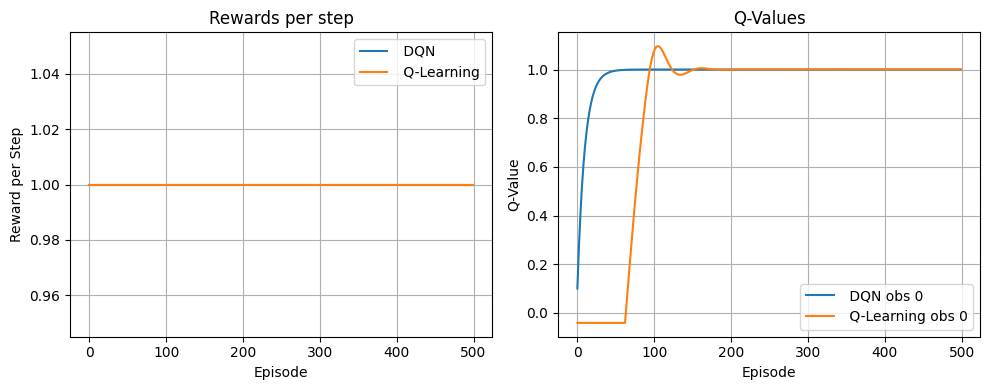

In [22]:
folder_name = "dqn/env1"
path = Path(f"../runs/{folder_name}")
tag = 'Reward per step/Episode'
episodes, values = load_from_tensorboard(path, tag)

ql_folder_name = "q_learning/env1"
path = Path(f"../runs/{ql_folder_name}")
tag = 'Reward per step/Episode'
ql_episodes, ql_values = load_from_tensorboard(path, tag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(episodes, values, label=" DQN")
axes[0].plot(ql_episodes, ql_values, label=" Q-Learning")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward per Step")
axes[0].grid(True)
axes[0].legend()
axes[0].set_title("Rewards per step")

path = Path(f"../runs/{folder_name}")
tag= "Q-values/Episode/state_0_action_0"
episodes, ql_values = load_from_tensorboard(path, tag)

path = Path(f"../runs/{ql_folder_name}")
tag= "Q-values/Episode/state_0_action_0"
ql_episodes, values = load_from_tensorboard(path, tag)

axes[1].plot(episodes, values, label=" DQN obs 0")
axes[1].plot(ql_episodes, ql_values, label=" Q-Learning obs 0")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Q-Value")
axes[1].legend()
axes[1].grid(True)
axes[1].set_title("Q-Values")

plt.tight_layout()

image_name = "dqn_ql_env1"
path = Path(f"../images/{image_name}.png")
if not path.parent.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(path, dpi=300)

plt.show()

### Env2

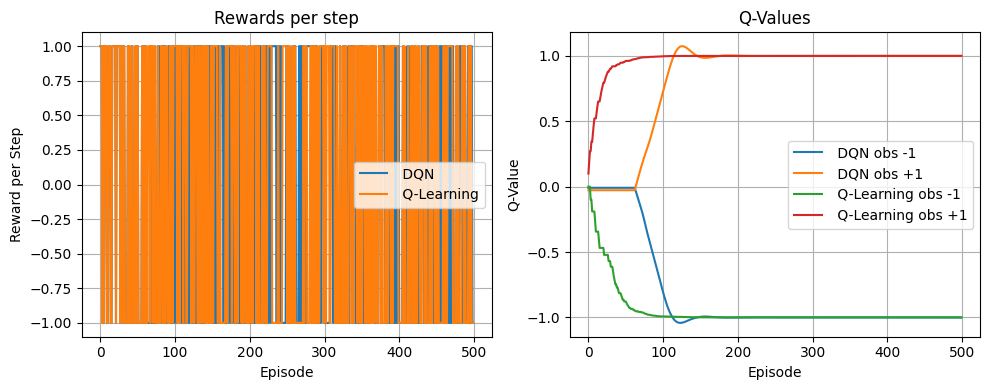

In [23]:
folder_name = "dqn/env2"
path = Path(f"../runs/{folder_name}")
tag = 'Reward per step/Episode'
episodes, values = load_from_tensorboard(path, tag)

ql_folder_name = "q_learning/env2"
path = Path(f"../runs/{ql_folder_name}")
tag = 'Reward per step/Episode'
ql_episodes, ql_values = load_from_tensorboard(path, tag)


fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(episodes, values, label=" DQN")
axes[0].plot(ql_episodes, ql_values, label=" Q-Learning")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward per Step")
axes[0].grid(True)
axes[0].legend()
axes[0].set_title("Rewards per step")

path = Path(f"../runs/{folder_name}")
tag= "Q-values/Episode/state_0_action_0"
episodes, values = load_from_tensorboard(path, tag)
tag= "Q-values/Episode/state_1_action_0"
episodes2, values2 = load_from_tensorboard(path, tag)


path = Path(f"../runs/{ql_folder_name}")
tag= "Q-values/Episode/state_0_action_0"
ql_episodes, ql_values = load_from_tensorboard(path, tag)

tag= "Q-values/Episode/state_1_action_0"
ql_episodes2, ql_values2 = load_from_tensorboard(path, tag)

axes[1].plot(episodes, values, label=" DQN obs -1")
axes[1].plot(episodes2, values2, label=" DQN obs +1")
axes[1].plot(ql_episodes, ql_values, label=" Q-Learning obs -1")
axes[1].plot(ql_episodes2, ql_values2, label=" Q-Learning obs +1")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Q-Value")
axes[1].legend()
axes[1].grid(True)
axes[1].set_title("Q-Values")

plt.tight_layout()
image_name = "dqn_ql_env2"
path = Path(f"../images/{image_name}.png")
if not path.parent.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(path, dpi=300)

plt.show()

### env3

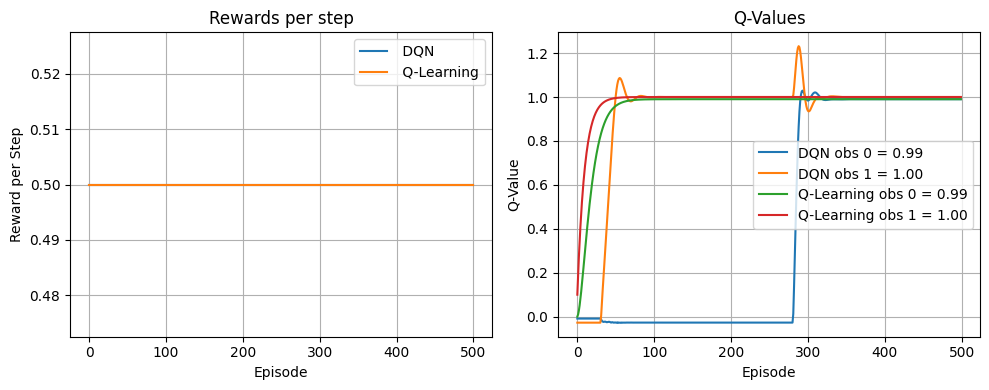

In [24]:
folder_name = "dqn/env3"
path = Path(f"../runs/{folder_name}")
tag = 'Reward per step/Episode'
episodes, values = load_from_tensorboard(path, tag)

ql_folder_name = "q_learning/env3"
path = Path(f"../runs/{ql_folder_name}")
tag = 'Reward per step/Episode'
ql_episodes, ql_values = load_from_tensorboard(path, tag)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(episodes, values, label=" DQN")
axes[0].plot(ql_episodes, ql_values, label=" Q-Learning")
axes[0].set_xlabel("Episode")
axes[0].set_ylabel("Reward per Step")
axes[0].grid(True)
axes[0].legend()
axes[0].set_title("Rewards per step")

path = Path(f"../runs/{folder_name}")
tag= "Q-values/Episode/state_0_action_0"
episodes, values = load_from_tensorboard(path, tag)
tag = "Q-values/Episode/state_1_action_0"
episodes2, values2 = load_from_tensorboard(path, tag)

path = Path(f"../runs/{ql_folder_name}")
tag= "Q-values/Episode/state_0_action_0"
ql_episodes, ql_values = load_from_tensorboard(path, tag)

tag= "Q-values/Episode/state_1_action_0"
ql_episodes2, ql_values2 = load_from_tensorboard(path, tag)

axes[1].plot(episodes, values, label= f"DQN obs 0 = {values[-1]:.2f}")
axes[1].plot(episodes2, values2, label= f"DQN obs 1 = {values2[-1]:.2f}")
axes[1].plot(ql_episodes, ql_values, label= f"Q-Learning obs 0 = {ql_values[-1]:.2f}")
axes[1].plot(ql_episodes2, ql_values2, label= f"Q-Learning obs 1 = {ql_values2[-1]:.2f}")
axes[1].set_xlabel("Episode")
axes[1].set_ylabel("Q-Value")
axes[1].legend()
axes[1].grid(True)
axes[1].set_title("Q-Values")

plt.tight_layout()

image_name = "dqn_ql_env3"
path = Path(f"../images/{image_name}.png")
if not path.parent.exists():
    path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(path, dpi=300)

plt.show()